In [ ]:
!pip install -q pyspark

In [ ]:
!apt-get update

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [ ]:
!update-alternatives --set java /usr/lib/jvm/java-8-openjdk-amd64/jre/bin/java

In [ ]:
!java -version

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.getenv("JAVA_HOME")

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import pyspark
import pyspark.sql.functions as F
import random
import scipy.stats as stats
import seaborn as sns
import tensorflow as tf
import tensorflow_probability as tfp
from ipywidgets import interact
from pyspark.sql import SparkSession

tfb = tfp.bijectors
tfd = tfp.distributions

%matplotlib inline

plt.style.use('fivethirtyeight')

In [ ]:
sc = SparkSession.builder.appName('LRAC-6330').getOrCreate()

#**LRAC-6330 - Researching ways to parallelize A/B Testing code in Spark**<hr span=30%></hr> 

**Description**

Research the possibility of run the AB Testing code using pymc3 in parallel with Spark. The key to do this is to run multiple Markov chains in parallel to accelerate convergence and to build a more robust model. Other options are to use Tensorflow Probability, but it requires more fine tuning and low level aspects of the lib and more deep knowledge of the math involved.<br><br>

This notebook contains the models described in the LRAC-6330 ticket and it's sub-tasks.<br><br><br>

##1. Input Data
---
This is the test data as described in the [repo]

In [ ]:
dataset = pd.DataFrame(
  data={
      'trials':[3025,2895,3200,3523,2065,1645],
      'successes':[2235,2132,1789,3002,1245,1135],
      'days':[1,2,1,2,1,2]
  },
  index=['Control','Control','Variant A','Variant A','Variant B','Variant B']
)

dataset

,trials,successes,days
Control,3025,2235,1
Control,2895,2132,2
Variant A,3200,1789,1
Variant A,3523,3002,2
Variant B,2065,1245,1
Variant B,1645,1135,2


In [ ]:
groups = dataset.groupby(dataset.index).agg({'trials':'sum','successes':'sum'})

groups

,trials,successes
Control,5920,4367
Variant A,6723,4791
Variant B,3710,2380


In [ ]:
probs = groups.assign(rate = lambda df: df['successes']/df['trials'])['rate']

probs

Control      0.737669
Variant A    0.712628
Variant B    0.641509
Name: rate, dtype: float64

#**LRAC-6567** - Implement Bayesian Multi-Armed Bandits algorithms in Pyspark/Tensorflow

##**Description**

Bayesiam Multi-Armed Bandits have been used as an alternative for Frequentist and bayesian A/B Testing. The aim of this ticket is to implement this algorithm using Tensorflow Probability to see if it'll be viable to research in the future.<br><br>

---

# **- Testing Framework -**

##**Simulating the Arms of a Bandit Problem**

In order to reasonably simulate what might happen if we were to deploy an epsilon-Greedy algorithm in production, we need to set up some hypothetical arms. For this, we're going to focus on a very simple type of simulated arm that's easy to implement correctly. This hypothetical arm will let us simulate settings like:<br>


* *Optimizing click-through rates for ads:* Every time we show someone an ad, we'll imagine that there's a fixed probability that they'll click on the ad. The bandit algorithm will then estimate this probability and try to decide on a strategy for showing ads that maximizes the click-through rate.
* *Conversion rates for new users:* Every time a new visitor comes to our site who isn't already a registered user, we'll imagine that there's a fixed probability that they'll register as a user after seeing the landing page. We'll then estimate this probability and try to decide on a strategy for maximizing our conversion rate.<br><br>



For this notebook, the following objects will be used for testing:

* **`BernoulliArm`** (class)
* **`test_bandits_algorithms`** (function)
* **`visualize_test`** (function)

The description of this objects/functions will be described in its respective sections.<br><br>




##  - The Variants of the test (**_Bernoulli Arms_**) -

Our simulated arm is going to be called a Bernoulli arm. Calling this type of an arm a Bernoulli arm is just a jargony way of saying that we’re dealing with an arm that rewards you with a value of 1 some percentage of the time and rewards you with a value of 0 the rest of the time. This 0/1 framework is a very simple way to simulate situations like click-through or user signups: the potential user arrives at your site; you select an arm for them in which you, for example, show them one specific color logo; finally, they either do sign up for the site (and give you reward 1) or they don’t (and give you reward 0). If 2% of people who see a red logo sign up and 5% of people who see a green logo sign up, then you can abstract away the details and talk about two arms: one arm outputs 1 unit of reward 2% of the time, the other arm outputs 1 unit of reward 5% of the time. This situation is what we call a Bernoulli arm.

In [ ]:
class BernoulliArm:

  def __init__(self, prob):
    self.prob = prob

  def draw(self):
    if (random.random() > self.prob):
      return 0.0
    else:
      return 1.0

# The testing framework

Our Multiarmed Bandit problem gets represented as an array of arm objects, each of which implements a `draw` method that simulates playing that specific arm.<br>

How does this testing framework work?

* We pass in a few objects:

 - A bandit algorithm that we want to test. (param: `algorithm`)
 - An array of arms (variants) we want to simulate draws from. (param: `arms`)
 - A fixed number of simulations to run to average over the noise in each simulation. (param: `num_simulations`)
 - The number of times each algorithm is allowed to pull on arms during each simulation. Any algorithm that's not terrible will eventually learn which arm is best; the interesting thing to study in a simulation is whether an algorithm does well when it only has 100 (or 100,000) tries to find the best arm. (param: `num_horizons`)

* The framework then uses these objects to run many independents simulations. For each of these, it:

  - Initializes the bandit algorithm's settings from scratch so that it has no prior knowledge about which arm is best.
  - Loops over opportunities to pull an arm. On each step of this loop, it:
    - Calls `select_arm`to see which arm the algorithm chooses.
    - Calls `draw` on that arm to simulate the result of pulling that arm.
    - Records the amount of reward received by the algorithm and then calls `update` to let the algorithm process that new piece of information.<br>

To show to use this testing framework, we need to pass in a specific algorithm and a specific set of arms. The parameterization that we'll use is as follows:

* **means**: The actual means of the variants used in the test. Bear in mind that in real world applications this quantities are unknown and can only be estimated. Since we are replicating the test data for the implemented A/B Testing feature, we are using the means of the `Control`, `Variant A` and `Variant B`. 
* **epsilon**: The main (and only) parameter of the epsilon-Greedy algorithm. A float between 0 and 1. We are testing with 5 values here.
* **num_simulations**: The number of simulations to simulate the noise of the random experiments.
* **num_horizons**: The number of times that a algorithm will be allowed to pull an arm (or to simulate a result from a given Variant).

In [ ]:
#Parameters and inputs

ALGORITHMS = {'epsilon-Greedy': None,
              'Annealing Epsilon Greedy': None,
              'Softmax':None,
              'Annealing Softmax': None,
              'UCB': None}

epsilon = [.1, .2, .3, .4, .5]

means = [0.737669, 0.712628, 0.641509]

num_arms = len(means)

np.random.shuffle(means)

arms = [BernoulliArm(mu) for mu in means]

index_of_best_arm = np.argmax(means)

num_horizons=500

num_simulations=5000

In [ ]:
#The test function

def test_bandits_algorithms(algorithm, arms, num_simulations, num_horizons):
  chosen_arms = np.zeros((num_simulations, num_horizons))
  rewards = np.zeros((num_simulations, num_horizons))

  for num_simulation in range(num_simulations):
    algorithm.initialize(len(arms))

    for num_horizon in range(num_horizons):
      chosen_arm = algorithm.select_arm()

      chosen_arms[num_simulation, num_horizon] = chosen_arm 

      reward = arms[chosen_arm].draw()
  
      rewards[num_simulation, num_horizon] = reward 

      algorithm.update(chosen_arm, reward)

  average_rewards = np.mean(rewards, axis=0)

  cumulative_rewards = np.cumsum(average_rewards)

  return chosen_arms, average_rewards, cumulative_rewards

# **Analyzing results from a Monte Carlo study**

## **Approach 1: Track the probability of choosing the best arm**

The first analytic approach, and certainly the simplest, is to keep track of the odds that our algorithm selects the best arm at any given point in time. We need to work with odds for two different reasons: (1) the algorithm uses randomization when choosing which arm to pull and may therefore not select the best arm even after it's learned which arm is best and (2) the rewards that algorithm will not make the best decision on any specific trial.<br>

As such, we'll explicitly calculate the probability of selecting the best arm by estimating the percentage of times in our simulations when the algorithm chose the best arm. If the probability that the algorithm picks the best arm doesn't go up over time, then we don't really have any evidence that our algorithm is learning anything about the values of the arms.

## **Approach 2: Track the Average reward at each point in time**

Instead of looking at the probability of picking the best arm, another simple approach to measuring our algorithm's performance is to use the average reward that our algorithm receives on each trial. When there are many arms similar to the best, each of which is just a little worse than the best, this average reward approach is a much better method of analysis than our approach using probabilities of selecting the best arm. 

## **Approach 3: Track the cumulative reward at each point in time**

Ultimately, there's something lacking in both of the approaches we've taken: they're too narrowly focused on the performance of the algorithm at each fixed point in time and don't give us a gestalt picture of the lifetime performance of our algorithm. This myopic focus on each point in time in isolation is unfair to versions of the epsilon-Greedy algorithm in which `epsilon`is large, because these algorithms, by definition, explore worse options more frequently than algorithms for which `epsilon`is low. This a sacrifice they intentionally make in order to explore faster. To decide whether that increased exploration is worth the trouble, we shouldn't focus on the performance of the algorithm at any specific point in time, but rather on its cumulative performance over time.

To do that, we can analyze the cumulative reward of our algorithms, which is simply the total amount of reward that an algorithm has won for us up until some fixed point in time. This cumulative reward is important, because it treats algorithms that do a lot of exploration at the start as a means of finding the best available arm more fairly.<br>

The 3 approaches discussed are implemented in the **`visualize_test`**function below.

In [ ]:
def visualize_test(
    algorithm_name, arms=None, best_arm_index=None, hyperparams=None,
    num_simulations=1000, num_horizons=100, label=None):

  fig_size=(18, 6)
  # Check if the algorithm doesn't have hyperparameter
  if hyperparams is None:
    # Run the algorithm
    algorithm = ALGORITHMS[algorithm_name]()

    chosen_arms, average_rewards, cum_rewards =(
      test_bandits_algorithms(algorithm, arms, num_simulations, num_horizons)
    )
 
    average_probs = (
      np.where(chosen_arms == best_arm_index, 1, 0).sum(axis=0) /
        num_simulations
    )

    # Plot the 3 metrics of the algorithm
    fig, axes = plt.subplots(1, 3, figsize=fig_size)
  
    axes[0].plot(average_probs)
    axes[0].set_xlabel("Time", fontsize=14)
    axes[0].set_ylabel("Probability of Selecting Best Arm", fontsize=14)
    axes[0].set_title(f"Accuray of {algorithm_name} alg.", y=1.05, fontsize=16)
    axes[0].set_ylim([0, 1.05])

    axes[1].plot(average_rewards)
    axes[1].set_xlabel("Time", fontsize=14)
    axes[1].set_ylabel("Average Reward", fontsize=14)
    axes[1].set_title(
        f"Avg. Rewards of {algorithm_name} alg.", y=1.05, fontsize=16)
    axes[1].set_ylim([0, 1.0])

    axes[2].plot(cum_rewards)
    axes[2].set_xlabel("Time", fontsize=14)
    axes[2].set_ylabel("Cumulative Rewards of Chosen Arm", fontsize=14)
    axes[2].set_title(
        f"Cumulative Rewards of {algorithm_name} alg.", y=1.05, fontsize=16)

    plt.tight_layout()
  else:
    fig, axes = plt.subplots(1, 3, figsize=fig_size)
    for hyperparam in hyperparams:
        # Run the algorithm
        algorithm = ALGORITHMS[algorithm_name](hyperparam)
      
        chosen_arms, average_rewards, cum_rewards = (
          test_bandits_algorithms(
              algorithm, arms, num_simulations, num_horizons)
        )

        average_probs = (
          np.where(chosen_arms == best_arm_index, 1, 0).sum(axis=0) /
            num_simulations
        )

        # Plot the 3 metrics of the algorithm
        axes[0].plot(average_probs, label=f"{label} = {hyperparam}")
        axes[0].set_xlabel("Time", fontsize=14)
        axes[0].set_ylabel("Probability of Selecting Best Arm", fontsize=14)
        axes[0].set_title(
            f"Accuray of {algorithm_name} alg.", y=1.05, fontsize=16)
        axes[0].legend()
        axes[0].set_ylim([0, 1.05])

        axes[1].plot(average_rewards, label=f"{label} = {hyperparam}")
        axes[1].set_xlabel("Time", fontsize=14)
        axes[1].set_ylabel("Average Reward", fontsize=14)
        axes[1].set_title(
            f"Avg. Rewards of {algorithm_name} alg.", y=1.05, fontsize=16)
        axes[1].legend()
        axes[1].set_ylim([0, 1.0])

        axes[2].plot(cum_rewards, label=f"{label} = {hyperparam}")
        axes[2].set_xlabel("Time", fontsize=14)
        axes[2].set_ylabel("Cumulative Rewards of Chosen Arm", fontsize=14)
        axes[2].set_title(
            f"Cumulative Rewards of {algorithm_name} alg.", y=1.05, fontsize=16)
        axes[2].legend(loc="lower right")

        plt.tight_layout()





# **Implementing the epsilon-Greedy algorithm**

Fields of the class:

**`epsilon`**<p></p>
>Floating point number that tells the frequency with which we should explore one of the available arms. Setting *epsilon* to 0.1 will allow the algorithm to explore the available arms on 10% of the pulls.

**`counts`**<p></p>
> A vector of integers of length **N** that tells us how many times we've played each of the **N** arms available to us in the current bandit problem. If there are 2 arms, Arm 1 and Arm 2, which have both been played twice, then we'll set *counts = [2, 2]*.

**`values`**<p></p>
>A vector of floating point numbers that defines the average amount of reward we've gotten when playing each of the **N** arms available to us. If Arm 1 gave us 1 unit of reward on one play and 0 on another play, while Arm 2 gave us 0 units of reward on both plays, then we'll set *values = [0.5, 0.0]*.

In [ ]:
class EpsilonGreedy:

  def __init__(self, epsilon=None, counts=None, values=None):
    self.epsilon = epsilon
    self.counts = counts
    self.values = values
    return

  def initialize(self, num_arms):
    self.counts = np.zeros(num_arms, dtype=int)
    self.values = np.zeros(num_arms, dtype=float)
    return

  def select_arm(self):
    if (np.random.random() > self.epsilon):
      return np.argmax(self.values)
    else:
      return np.random.randint(0, len(self.values))

  def update(self, chosen_arm, reward):
    self.counts[chosen_arm] =+ 1

    count = self.counts[chosen_arm]
    value = self.values[chosen_arm]

    new_value = (
      (((count - 1) / float(count)) * value) + ((1 / float(count)) * reward)
    )

    self.values[chosen_arm] = new_value
    return


CPU times: user 2min 20s, sys: 1.01 s, total: 2min 21s
Wall time: 2min 20s


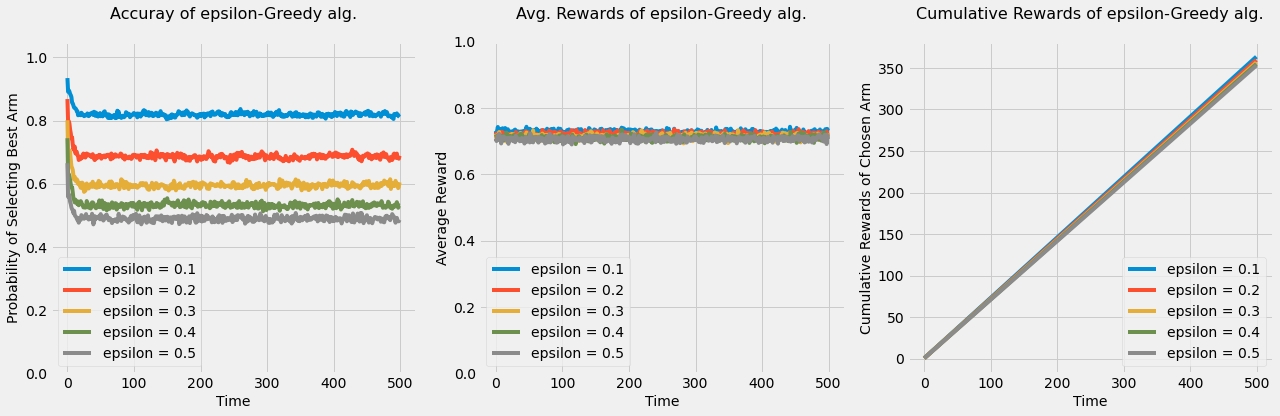

In [ ]:
%%time 
name = 'epsilon-Greedy'

ALGORITHMS[name] = EpsilonGreedy

visualize_test(
    name, arms=arms, best_arm_index=index_of_best_arm, hyperparams=epsilon, 
    num_simulations=num_simulations, num_horizons=num_horizons, label='epsilon')

# **Implementing the epsilon-Greedy with a dynamic epsilon**

The problem of the standard version of the epsilon-Greedy algorithm is that it explores options completely at random without any concern about their merits. For example, in on scenario (call it Scenario A), you might have two arms, one of which rewards you 10% of the time and the other rewards you 13% of the time. In Scenario B, the two arms might reward you 10% of the time and 99% of the time. In both of these scenarios, the probability that the epsilon-Greedy algorithm explores the worse arm is exactly the same (it's epsilon / 2) despite the inferior arm in Scenario B being, in relative terms, much worse than the inferior arm in Scenario A.

This is a problem for several reasons:
 * If the difference in reward rates between two arms is small, you’ll need to explore a lot more often than 10% of the time to correctly determine which of the two options is actually better.
 * In contrast, if the difference is large, you need to explore a lot less than 10% of the time to correctly estimate the better of the two options. For that reason, you’ll end up losing a lot of reward by exploring an unambiguously inferior option in this case. When we first described the epsilon-Greedy algorithm, we said that we wouldn’t set epsilon = 1.0 precisely so that we wouldn’t waste time on inferior options, but, if the difference between two arms is large enough, we end up wasting time on inferior options simply because the epsilon-Greedy algorithm always explores completely at random.


 Putting these two points together, it seems clear that there’s a qualitative property miss‐ ing from the epsilon-Greedy algorithm. We need to make our bandit algorithm care about the known differences between the estimated values of the arms when our algorithm decides which arm to explore. We need *structured exploration* rather than the *haphazard exploration* that the epsilon-Greedy algorithm provides. 

 The *Annealing* version of the epsilon-Greedy is implemented overriding the `select_arm` method of the class by decaying the epsilon value over time.

In [ ]:
class AnnealingEpsilonGreedy(EpsilonGreedy):

  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)

  def select_arm(self):
    counts = np.sum(self.counts) + 1
    epsilon = 1 / np.log(counts + 0.0001)

    if (np.random.random() > epsilon):
      return np.argmax(self.values)

    return np.random.randint(0, len(self.values))

CPU times: user 1min 15s, sys: 2.73 s, total: 1min 18s
Wall time: 1min 14s


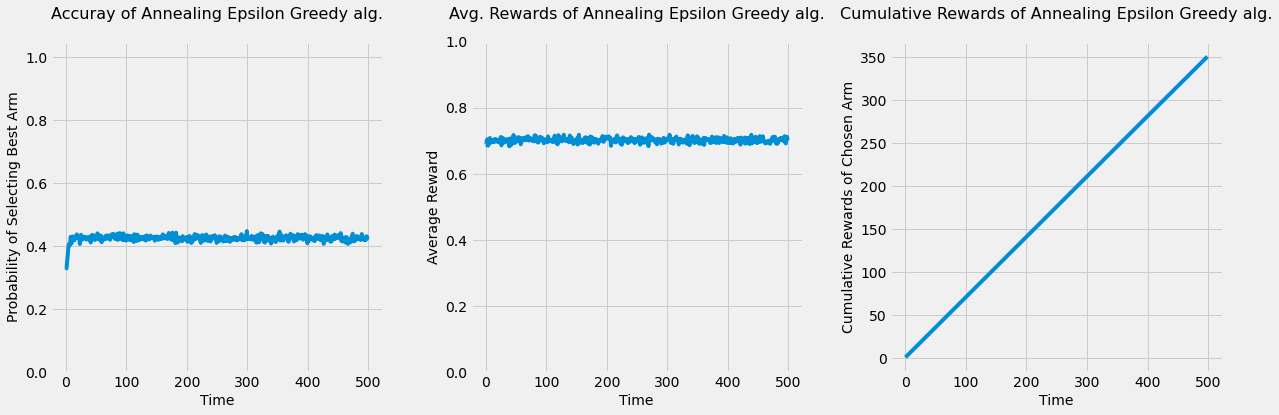

In [ ]:
%%time

name = 'Annealing Epsilon Greedy'

ALGORITHMS[name] = AnnealingEpsilonGreedy

visualize_test(
    name, arms=arms, best_arm_index=index_of_best_arm, hyperparams=None, 
    num_simulations=num_simulations, num_horizons=num_horizons, label=None)

# **Implementing the Softmax algorithm**

The Softmax algorithm tries to cope with arms differing in estimated value by explicitly incorporating information about the reward rates of the available arms into its method for choosing which arm to select when it explores.

You can get an initial intuition for how the Softmax algorithm handles this problem by imagining that you choose each arm in proportion to its estimated value. Suppose that you have two arms, A and B. Now imagine that, based on your past experiences, these two arms have had two different rates of success: rA and rB. With those assumptions, the most naive possible implementation of a Softmax-like algorithm would have you choose Arm A with probability rA / (rA + rB) and Arm B with probability rB / (rA + rB).

In practice, this very naive algorithm isn’t something people actually use. To reconstruct the algorithm people actually use, we need to make two changes to it.
First, we will calculate a different scale for reward rates by exponentiating our estimates of rA and rB. Using this new scale, we will choose Arm A with probability exp(rA) / (exp(rA) + exp(rB)) and Arm B with probability exp(rB) / (exp(rA) + exp(rB)). This naive exponential rescaling has the virtue of not behaving strangely if you someone used negative numbers as rates of success, since the call to exp will turn any negative numbers into positive numbers and insure that the negative numbers in the denominator of these fractions can’t cancel out any positive numbers that may be found in the denominator.
 34 | Chapter 5: The Softmax Algorithm
More importantly, this exponentiation trick brings us very close to the full Softmax algorithm. In fact, plain exponential rescaling gives us the Softmax algorithm if you hardcoded one of the configurable parameters that the standard Softmax algorithm possesses. This additional parameter is a different sort of scaling factor than the exponentiation we just introduced.
This new type of scaling factor is typically called a temperature parameter based on an analogy with physics in which systems at high temperatures tend to behave randomly, while they take on more structure at low temperatures. In fact, the full Softmax algorithm is closely related to a concept called the Boltzmann distribution in physics, which is used to describe how groups of particles behave.

In [ ]:
class Softmax:

  def __init__(self, temperature=.5, counts=None, values=None):
    self.temperature=temperature
    self.counts=counts
    self.values=values
    return

  @staticmethod
  def categorical_draw(probs):
    predictions = np.random.multinomial(1, probs, 1)
    return np.argmax(predictions)

  def initialize(self, num_arms):
    self.counts = np.zeros(num_arms, dtype=int)
    self.values = np.zeros(num_arms, dtype=float)
  
  def select_arm(self):
    scale_factor = self.values / self.temperature
    probs = np.exp(scale_factor) / np.sum(np.exp(scale_factor))

    return Softmax.categorical_draw(probs)

  def update(self, chosen_arm, reward):
    self.counts[chosen_arm] += 1

    count = self.counts[chosen_arm]
    value = self.values[chosen_arm]

    new_value = (
      (((count - 1) / float(count)) * value) + ((1 / float(count)) * reward)
    )

    self.values[chosen_arm] = new_value
    return

CPU times: user 10min 2s, sys: 3.77 s, total: 10min 6s
Wall time: 10min 1s


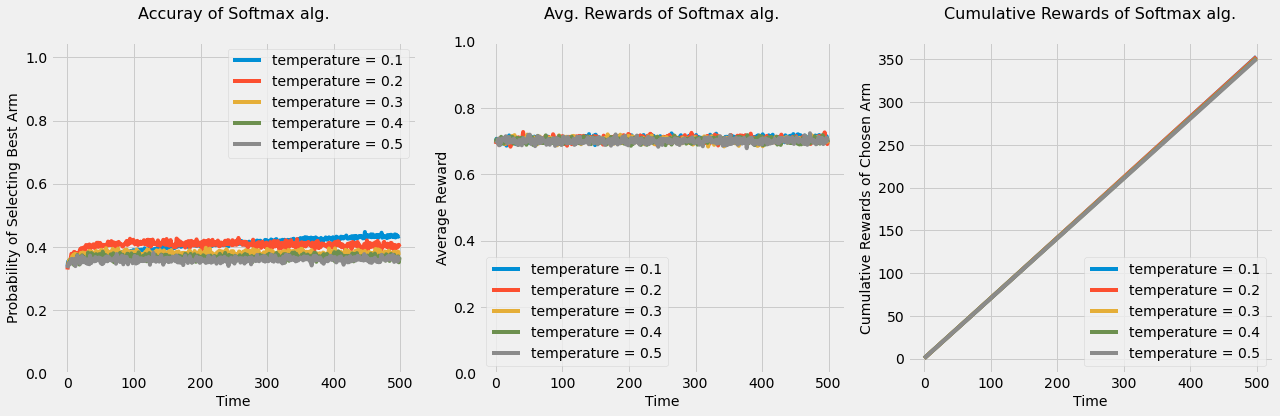

In [ ]:
%%time 
name = 'Softmax'

ALGORITHMS[name] = Softmax

temperature = [.1, .2, .3, .4, .5]

visualize_test(
    name, hyperparams=temperature, arms=arms, best_arm_index=index_of_best_arm,
    num_simulations=num_simulations, num_horizons=num_horizons, 
    label='temperature')

# **The annealing Softmax algorithm**

On testing the epsilon-Greedy algorithm, it’s often a good idea to encourage an algorithm to explore less over time. In the Softmax algorithm, we can achieve that by slowly decreasing the temperature, which we call annealing. The name annealing is based on a metaphor about blacksmithing. For a blacksmith, annealing is a process in which the blacksmith slowly decreases the tem‐ perature at which he works with molten melt so that it becomes more solid and less flexible. This is helpful for building stronger materials as the metal gets closer to its final, desired shape. For bandit algorithms, we can metaphorically decrease the temperature by changing the temperature parameter. This will make our algorithm exploit the best arm more often and settle into its final deterministic strategy for choosing an arm. 

In [ ]:
class AnnealingSoftmax(Softmax):

  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)
    return
  
  def select_arm(self):
    counts = np.sum(self.counts) + 1

    temperature = 1 / np.log(counts + 0.000001)

    scale_factor = self.values / temperature

    probs = np.exp(scale_factor) / np.sum(np.exp(scale_factor))

    return Softmax.categorical_draw(probs)

CPU times: user 2min 40s, sys: 2.2 s, total: 2min 43s
Wall time: 2min 39s


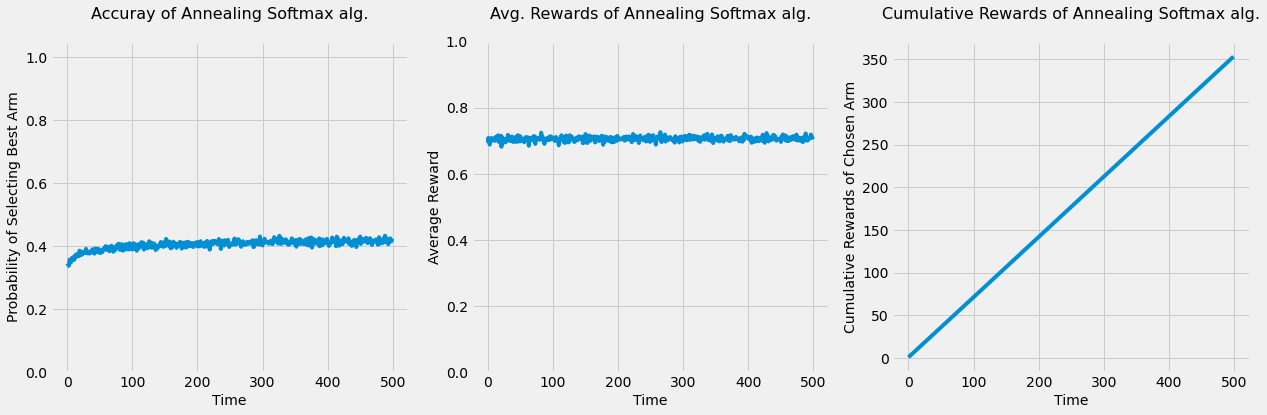

In [ ]:
%%time

name = 'Annealing Softmax'

ALGORITHMS[name] = AnnealingSoftmax

visualize_test(
    name, hyperparams=None, arms=arms, best_arm_index=index_of_best_arm,
    num_simulations=num_simulations, num_horizons=num_horizons)

# **UCB - The Upper Confidence Bound algorithm**

The algorithms we’ve presented so far have one systematic weakness: they don’t keep track of how much they know about any of the arms available to them. They pay attention only to how much reward they’ve gotten from the arms. This means that they’ll under‐ explore options whose initial experiences were not rewarding, even though they don’t have enough data to be confident about those arms. We can do better by using an al‐ gorithm that pays attention to not only what it knows, but also how much it knows.


Before we describe how the **UCB** algorithm keeps track of how much it knows, let’s look back at the epsilon-Greedy and Softmax algorithms and take a more abstract perspective on them. Both the epsilon-Greedy algorithm and the Softmax algorithm share the following broad properties:
 *  The algorithm’s default choice is to select the arm that currently has the highest estimated value.
 *  The algorithm sometimes decides to explore and chooses an option that isn’t the one that currently seems best:
  -  The epsilon-Greedy algorithm explores by selecting from all of the arms completely at random. It makes one of these random exploratory decisions with probability `epsilon`.
  - The Softmax algorithm explores by randomly selecting from all of the available arms with probabilities that are more-or-less proportional to the estimated value of each of the arms. If the other arms are noticeably worse than the best arm, they’re chosen with very low probability. If the arms all have similar values, they’re each chosen nearly equally often.
 * In order to achieve better performance by making an effort to have these two al‐ gorithms explore less over time, both algorithms can be set up to modify their basic parameters dynamically over time. We called this modification annealing.


Looking at this list, we can see how **UCB** can improve upon the epsilon-Greedy and Softmax algorithms: it can make decisions to explore that are driven by our confidence in the estimated value of the arms we’ve selected.
Why is it important to keep track of our confidence in the values of the arms? The reason has to do with the nature of the rewards we receive from the arms: they’re noisy. If we use our past experiences with an arm, then the estimated value of any arm is always a noisy estimate of the true return on investment we can expect from it. Because of this noise, it might just be a coincidence that Arm A seems better than Arm B; if we had more experience with both arms, we’d eventually realize that Arm B is actually better. The epsilon-Greedy and Softmax algorithms aren’t robust to this noise during their first experiences with things.
Or, to put things in more human terms, the epsilon-Greedy and Softmax algorithms are gullible. They are easily misled by a few negative experiences. Because of their use of randomness, they can make up for this later. **UCB** takes a very different approach. **UCB** does not use randomness at all.

Instead, **UCB** avoids being gullible by requiring us to keep track of our confidence in our assessments of the estimated values of all of the arms. To do that, we need to have some metric of how much we know about each arm.




In [ ]:
class UCB:
  def __init__(self, counts=None, values=None):
    self.counts = counts
    self.values = values
    return

  def initialize(self, num_arms):
    self.counts = np.zeros(num_arms, dtype=int)
    self.values = np.zeros(num_arms, dtype=float)
    return

  def select_arm(self):
    num_arms = len(self.counts)

    for num_arm in range(num_arms):
      if self.counts[num_arm] == 0:
        return num_arm
    
    ucb_values = np.zeros(num_arms)
    counts = np.sum(self.counts)

    for num_arm in range(num_arms):
      bonus = np.sqrt((2 * np.log(counts)) / self.counts[num_arm])
      ucb_values[num_arm] = self.values[num_arm] + bonus
    
    return np.argmax(ucb_values)

  
  def update(self, chosen_arm, reward):
    self.counts[chosen_arm] += 1

    counts = self.counts[chosen_arm]
    value = self.values[chosen_arm]

    new_value = (
      (((counts - 1) / float(counts)) * value) + ((1 / float(counts)) * reward)
    )

    self.values[chosen_arm] = new_value
    return


CPU times: user 1min 49s, sys: 2.95 s, total: 1min 52s
Wall time: 1min 48s


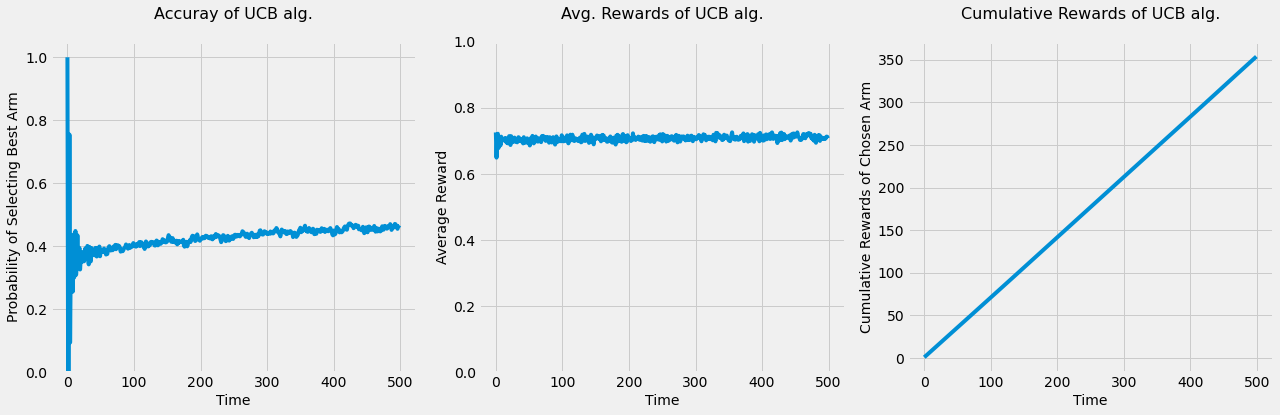

In [ ]:
%%time

name = 'UCB'

ALGORITHMS[name] = UCB

visualize_test(
  name, arms=arms, best_arm_index=index_of_best_arm,
  num_simulations=num_simulations,num_horizons=num_horizons)